In [ ]:
PCA
principal Component analysis is a diminsionality reduction technique
transform correlated ffeaturesinto a new set of uncorrelated variables called principal component(PC)
each component captures as much variance from the data s possible

In [1]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
X, y = make_classification(
    n_samples = 500,
    n_features = 8,
    n_informative = 5,
    n_redundant=2,
    n_classes= 2,
    random_state=42
)

feature_names =[f"Feature_{i}" for i in range(1,9)]
X = pd.DataFrame(X, columns=feature_names)
y= pd.Series(y, name ="Target")

print("Shape of the dataset:",X.shape)
X.head()

Shape of the dataset: (500, 8)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8
0,0.332065,2.124703,-3.061325,0.004672,-0.458937,-0.783128,4.351506,-1.105799
1,-0.238338,2.936671,3.929601,4.876240,-2.636280,0.776127,-0.278312,4.443385
2,-1.702213,-1.998193,-0.913099,-3.602779,4.120838,3.378124,-0.585943,-0.028662
3,0.428791,0.919849,-1.525197,0.923322,-1.587194,-2.145729,1.999563,-1.014990
4,-3.324756,1.343036,-1.563851,-3.021339,1.328555,0.916165,0.608482,-3.123425


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f"PC{i}" for i in range(1,9)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

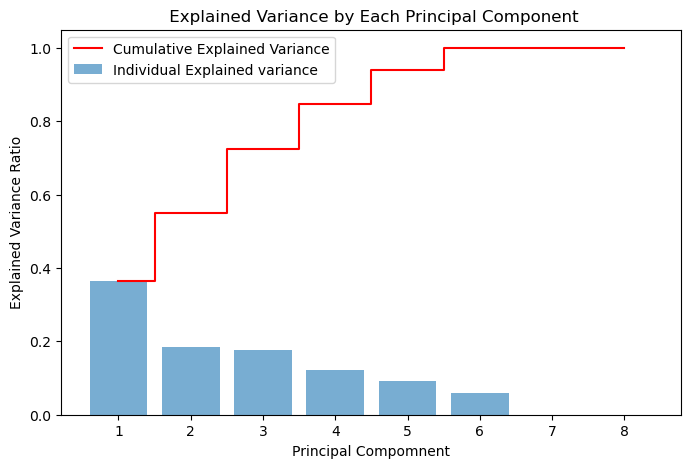

In [9]:
# visualization 

explained_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(explained_var_ratio)

plt.figure(figsize=(8,5))
plt.bar(range(1,9), explained_var_ratio, alpha =0.6, label="Individual Explained variance")
plt.step(range(1,9), cum_var_ratio, where='mid', label ="Cumulative Explained Variance", color='red')
plt.xlabel("Principal Compomnent")
plt.ylabel("Explained Variance Ratio")
plt.title(" Explained Variance by Each Principal Component")
plt.legend()
plt.show()

In [13]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

X_pca_2d_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
X_pca_2d_df["Target"]=y                           

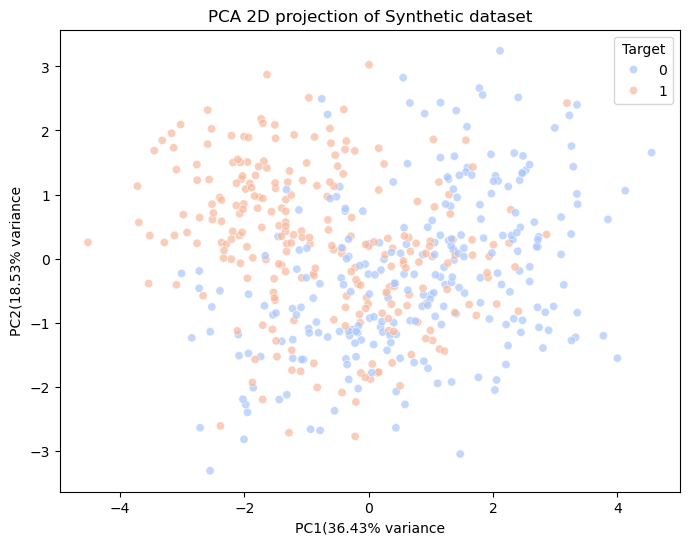

In [14]:
# visualize 2D projection
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_2d_df,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="coolwarm",
    alpha=0.7
)
plt.title("PCA 2D projection of Synthetic dataset")
plt.xlabel(f"PC1({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance")
plt.ylabel(f"PC2({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance")
plt.legend(title="Target")
plt.show()